# DIL Experiment

## Imports

In [52]:
# automatically reload updated modules when they change during development
%load_ext autoreload
%autoreload 2

# External modules

import torch
import numpy as np
import random
import gc
from copy import deepcopy

# Internal modules

from data_analysis_fcns.DIL_Logger import DIL_Logger
from data_analysis_fcns.DIL_Metrics import plot_results
from data_analysis_fcns import count_parameters, plot_expert_loads

from dataset_fcns import plot_partition_distributions
from dataset_fcns.replay import ReplayBuffer

from experiment_fcns import load_config
from experiment_fcns.experiment_utils import (
    evaluate_accuracy,
    _norm_seed,
    _maybe_update_router,
    evaluate_full_test,
    _make_scheduler_for_optimizer,
    _make_optimizer_for_model,
    compute_aux_loss
)

# CUDA check

print("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cuda


## Configuration from file and partitioning

Loading experiment configuration from configs/debug.jsonc
 dataset         : cifar10 @ ./datasets
 partitions      : 5  type=dirichlet 
 model           : vit_moe
 patch_size       : 8
 epochs_per_domain  : 1
{
  "seeds": {
    "global": 0
  },
  "dataset": "cifar10",
  "dataset_root": "./datasets",
  "mini_dataset": 1000,
  "resize": 0,
  "augmentation": {
    "random_resize_crop": true,
    "resize": 32,
    "random_flip": true,
    "color_jitter": true,
    "blur": true,
    "noise": true
  },
  "num_partitions": 5,
  "partition": {
    "type": "dirichlet",
    "alpha": 0.3,
    "min_size": 10,
    "balanced": true
  },
  "train_frac": 0.8,
  "batch_size": 128,
  "shuffle": true,
  "model": {
    "name": "vit_moe",
    "num_classes": 10,
    "pretrained": false,
    "patch_size": 8,
    "moe_layer_indices": "every_other",
    "moe_num_unshared_experts": 4,
    "moe_num_shared_experts": 1,
    "moe_top_k": 1,
    "moe_route_with_cls_token": true
  },
  "loss": {
    "name": "focal",


Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\queues.py", line 259, in _feed
Exception ignored in: <function _ConnectionBase.__del__ at 0x000001A96D867A60>
Traceback (most recent call last):
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\connection.py", line 133, in __del__
    self._close()
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\connection.py", line 282, in _close
    reader_close()
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\connection.py", line 178, in close
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid
    self._close()
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\connection.py", line 282, in _close
    _CloseHandle(self._handle)
OSError: [WinError 6] The handle is invalid

During handling 

Baseline will be computed after pretraining, from post-pretrain weights


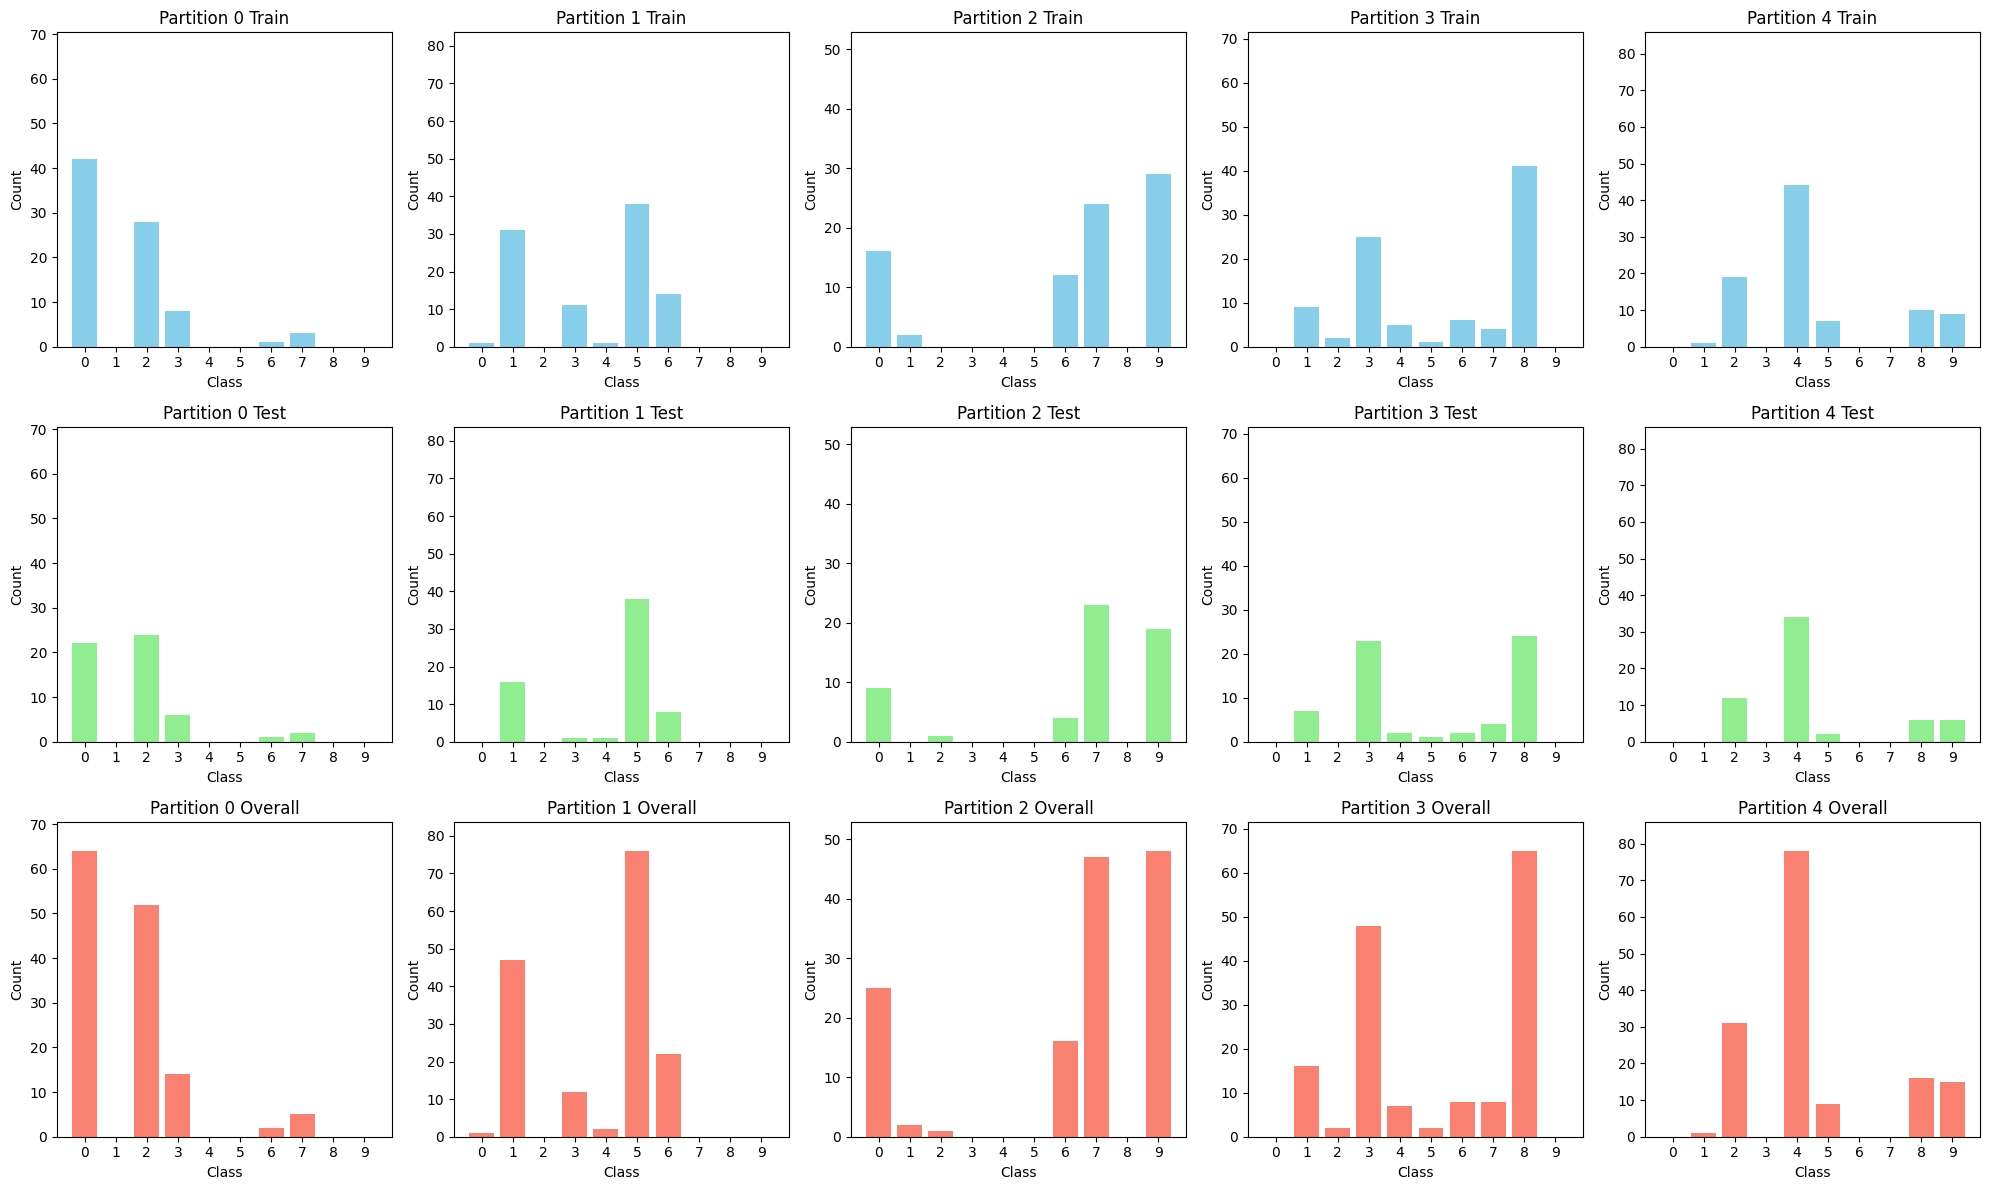

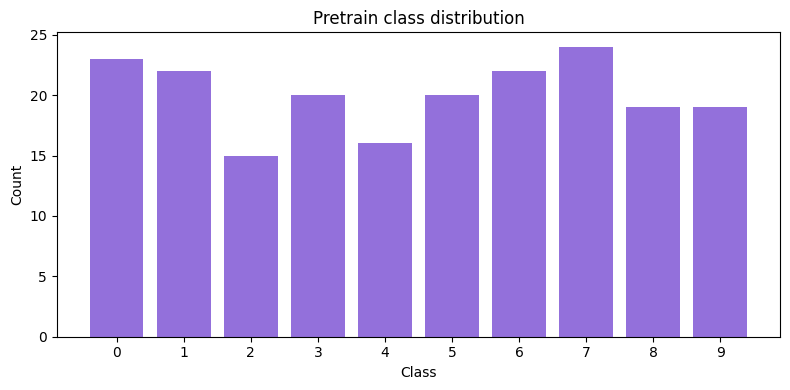

In [53]:
# ----------------------------------------
# Reproducibility and configuration
# ----------------------------------------

cfg_file = "configs/debug.jsonc"  # change as needed
setup = load_config(cfg_file)
# note: loader will automatically insert `img_size` into cfg['model'] based
# on the first batch so you generally don't need to specify it manually.
cfg = setup["cfg"]

device = setup["device"]

# objects returned by the loader
train_loaders = setup["train_loaders"]
test_loaders = setup["test_loaders"]
pretrain_loader = setup.get("pretrain_loader", None)
dataset = setup["dataset"]

num_classes = cfg.get("model", {}).get("num_classes", 10)
num_domains = len(train_loaders)
epochs_per_domain = cfg.get("epochs_per_domain", 5)

# optional baseline training (simple per-domain models to compute reference accuracies)
baseline_accs = None
if cfg.get("baseline", {}).get("train", False):
    baseline_accs = []
    print("Baseline will be computed after pretraining, from post-pretrain weights")

partition_distributions = setup.get("partition_distributions")
plot_partition_distributions(class_distributions=partition_distributions, num_classes=num_classes)

## Model, optimizer, scheduler, loss, logger

In [54]:
# ----------------------------------------
# Model, optimizer, scheduler, loss
# ----------------------------------------

model = setup["model"].to(device)
optimizer = setup["optimizer"]
criterion = setup["criterion"]
# move loss to device as well (especially for weighted/focal)
if hasattr(criterion, "to"):
    criterion = criterion.to(device)

scheduler = setup.get("scheduler", None)
pretrain_scheduler = setup.get("pretrain_scheduler", None)

# ----------------------------------------
# Continual Logger
# ----------------------------------------
baseline_val = baseline_accs if 'baseline_accs' in globals() and baseline_accs is not None else None
if baseline_val is None and cfg.get("baseline", {}).get("enabled", False):
    baseline_val = cfg.get("baseline", {}).get("accuracies", None)
    print("Using baseline accuracies from config for metric computation")
elif baseline_val is not None:
    print("Using computed baseline accuracies for metric computation")
logger = DIL_Logger(
    N=num_domains,
    C=num_classes,
    baseline=baseline_val,
    config_file=cfg_file,
)
# attach resolved seeds (from setup) so they are saved with the log
resolved_seeds = setup.get("resolved_seeds", None)
if resolved_seeds is not None:
    logger.seeds = resolved_seeds



Using computed baseline accuracies for metric computation


## Helper fcns for training

In [55]:
# ----------------------------------------
# Training helpers
# ----------------------------------------

# replay buffer
replay_cfg = cfg.get("replay", {})
replay_buffer = None
if replay_cfg.get("enabled", False):
    replay_buffer = ReplayBuffer(
        capacity=replay_cfg.get("capacity", 1000),
        policy=replay_cfg.get("policy", "fifo"),
    )

# parameter counts
total_params, active_params = count_parameters(model)
print(f"Model parameters: total={total_params:,}, active={active_params:,}")

# optionally print model structure
print(model)

Model parameters: total=8,335,514, active=4,785,050
ViTMoE(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0): TransformerBlockMoE(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=768, out_features=192, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (1): TransformerBlockMoE(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_featur

## Training loop

In [56]:
# ----------------------------------------
# Training loop
# ----------------------------------------

# We use resolved seeds returned by load_config to control per-stage seeding.
resolved_seeds = setup.get("resolved_seeds", {})
raw_seeds_spec = cfg.get("seeds", {}) if cfg is not None else {}

global_step = 0
global_epoch = 0
router_frozen = False

# ---------------------------------------------
# Pretraining stage (optional)
# ---------------------------------------------

if cfg.get("pretrain", {}).get("enabled", False) and pretrain_loader is not None:
    # determine pretrain seed behaviour
    pretrain_spec = raw_seeds_spec.get("pretrain", None)
    pretrain_seed = resolved_seeds.get("pretrain") if resolved_seeds is not None else None

    if pretrain_seed is not None:
        torch.manual_seed(pretrain_seed)
        np.random.seed(pretrain_seed)
        random.seed(pretrain_seed)
        print(f"Applied pretrain seed: {pretrain_seed}")
    elif isinstance(pretrain_spec, str) and pretrain_spec.lower() == "random":
        import os
        rand_seed = int.from_bytes(os.urandom(8), 'big') % (2**32 - 1)
        torch.manual_seed(rand_seed)
        np.random.seed(rand_seed)
        random.seed(rand_seed)
        print("Using randomized seed for pretrain stage")

    print("===== Pretraining stage =====")
    epochs_pretrain = cfg.get("pretrain", {}).get("epochs", epochs_per_domain)
    for epoch in range(epochs_pretrain):
        model.train()
        for x, y in pretrain_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if replay_buffer is not None:
                rx, ry = replay_buffer.sample(y.size(0))
                if rx.numel() > 0:
                    rx, ry = rx.to(device), ry.to(device)
                    rlogits = model(rx)
                    loss = loss + criterion(rlogits, ry)
            aux = compute_aux_loss(model, cfg)
            if isinstance(aux, torch.Tensor):
                loss = loss + aux
            loss.backward()
            optimizer.step()
            global_step += 1
            if replay_buffer is not None:
                replay_buffer.add_batch(x.cpu(), y.cpu())

        if pretrain_scheduler is not None:
            pretrain_scheduler.step()

        optimizer, router_frozen = _maybe_update_router(cfg, model, optimizer, pretrain_scheduler, global_epoch, router_frozen)
        global_epoch += 1

    # after completing all pretraining epochs, evaluate on full test set once
    pretrain_acc, pretrain_conf = evaluate_full_test(model, test_loaders, device, num_classes)
    print(f"Pretraining complete ({epochs_pretrain} epochs). Full test acc: {pretrain_acc:.4f}")
    # store pretrain confusion separately for later comparison
    logger.pretrain_confusion = pretrain_conf

# ---------------------------------------------
# Baseline models from post-pretrain weights
# ---------------------------------------------
if cfg.get("baseline", {}).get("train", False):
    print("===== Baseline model stage =====")

    post_pretrain_state = deepcopy(model.state_dict())
    baseline_accs = []
    freeze_router_flag = cfg.get("router_freeze_after_epochs") is not None or cfg.get("router_freeze_after_batches") is not None
    multiplier_defined = cfg.get("router_lr_multiplier") is not None
    use_router_balancing = cfg.get("router_balancing", False) and not (freeze_router_flag or multiplier_defined)

    # apply baseline seed if provided
    baseline_spec = raw_seeds_spec.get("baseline", None)
    baseline_seed = resolved_seeds.get("baseline") if resolved_seeds is not None else None
    if baseline_seed is not None:
        torch.manual_seed(baseline_seed)
        np.random.seed(baseline_seed)
        random.seed(baseline_seed)
        print(f"Applied baseline seed: {baseline_seed}")
    elif isinstance(baseline_spec, str) and baseline_spec.lower() == "random":
        import os
        rand_seed = int.from_bytes(os.urandom(8), 'big') % (2**32 - 1)
        torch.manual_seed(rand_seed)
        np.random.seed(rand_seed)
        random.seed(rand_seed)
        print("Using randomized seed for baseline stage")

    for domain_id in range(num_domains):
        bmodel = deepcopy(model)
        bmodel.to(device)
        # ensure baseline bmodel starts at the exact post-pretrain weights
        # strict=False allows load when some extra keys like pos_embed are present
        # due to model wrapping or slight architecture differences.
        missing, unexpected = bmodel.load_state_dict(post_pretrain_state, strict=False)
        if missing or unexpected:
            print(f"Baseline model state_dict load mismatch: missing={missing}, unexpected={unexpected}")
        boptimizer = _make_optimizer_for_model(bmodel, cfg=cfg)
        bscheduler = _make_scheduler_for_optimizer(boptimizer, cfg=cfg, epochs_per_domain=epochs_per_domain)

        if freeze_router_flag and hasattr(bmodel, "freeze_routing"):
            bmodel.freeze_routing(True)
        if multiplier_defined and hasattr(bmodel, "adjust_router_learning_rate"):
            boptimizer = bmodel.adjust_router_learning_rate(boptimizer, cfg.get("router_lr_multiplier", 1.0))

        for epoch in range(epochs_per_domain):
            bmodel.train()
            for x, y in train_loaders[domain_id]:
                x, y = x.to(device), y.to(device)
                boptimizer.zero_grad()
                logits = bmodel(x)
                loss_b = criterion(logits, y)
                if use_router_balancing:
                    aux_b = compute_aux_loss(bmodel, cfg)
                    if isinstance(aux_b, torch.Tensor):
                        loss_b = loss_b + aux_b
                loss_b.backward()
                boptimizer.step()
            if bscheduler is not None:
                bscheduler.step()

        acc = evaluate_accuracy(bmodel, test_loaders[domain_id], device)
        # compute full-test confusion for baseline bmodel for comparison
        full_acc, full_conf = evaluate_full_test(bmodel, test_loaders, device, num_classes)
        baseline_accs.append(acc)
        # store baseline confusion per domain in the logger
        if not hasattr(logger, 'baseline_confusions'):
            logger.baseline_confusions = []
        logger.baseline_confusions.append(full_conf)
        del bmodel, boptimizer, bscheduler
        gc.collect()
    print("Baseline accuracies per domain:", baseline_accs)
    # Add the new baselines to the logger for being able to calculate metrics
    logger.baseline = baseline_accs

# ---------------------------------------------
# Apply training seed
# ---------------------------------------------
training_spec = raw_seeds_spec.get("training", None)
training_seed = resolved_seeds.get("training") if resolved_seeds is not None else None
if training_seed is not None:
    torch.manual_seed(training_seed)
    np.random.seed(training_seed)
    random.seed(training_seed)
    print(f"Applied training seed: {training_seed}")
elif isinstance(training_spec, str) and training_spec.lower() == "random":
    import os
    rand_seed = int.from_bytes(os.urandom(8), 'big') % (2**32 - 1)
    torch.manual_seed(rand_seed)
    np.random.seed(rand_seed)
    random.seed(rand_seed)
    print("Using randomized seed for training stage")

# ---------------------------------------------
# Continual domain training
# ---------------------------------------------

print("===== Main model stage =====")
for domain_id in range(num_domains):
    print(f"\n===== Training Domain {domain_id} =====")
    train_loader = train_loaders[domain_id]

    # update loss weights if supported
    if hasattr(criterion, "update_weights"):
        try:
            indices = train_loader.dataset.indices
            base = train_loader.dataset.dataset
        except Exception:
            indices = None
            base = train_loader.dataset
        if indices is not None:
            labels = [base[i][1] for i in indices]
            labels = np.array(labels)
        else:
            labs = []
            for _, y in train_loader:
                labs.append(y.cpu().numpy())
            labels = np.concatenate(labs) if labs else np.array([])
        counts = np.bincount(labels, minlength=num_classes)
        criterion.update_weights(counts, cumulative=getattr(criterion, '_weight_cumulative', False))
        if hasattr(criterion, 'weights'):
            print(f"Updated loss weights for domain {domain_id}: {criterion.weights}")

    for epoch in range(epochs_per_domain):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            if replay_buffer is not None:
                rx, ry = replay_buffer.sample(y.size(0))
                if rx.numel() > 0:
                    rx, ry = rx.to(device), ry.to(device)
                    rlogits = model(rx)
                    loss = loss + criterion(rlogits, ry)

            # auxiliary loss (router balancing etc.)
            aux = compute_aux_loss(model, cfg)
            if isinstance(aux, torch.Tensor):
                loss = loss + aux
            loss.backward()
            optimizer.step()
            global_step += 1
            if replay_buffer is not None:
                replay_buffer.add_batch(x.cpu(), y.cpu())

        if scheduler is not None:
            scheduler.step()

        optimizer, router_frozen = _maybe_update_router(cfg, model, optimizer, scheduler, global_epoch, router_frozen)

        domain_acc, overall_acc, preds, targets = logger.evaluate(model, test_loaders, device)
        # pass preds/targets so logger can compute and store epoch confusion
        metrics = logger.compute_metrics(domain_id, epoch, domain_acc, preds=preds, targets=targets)
        metrics["overall_acc"] = float(overall_acc)
        logger.log(metrics)

        print(
            f"Epoch {epoch+1} | "
            f"Domain: {domain_acc[domain_id]:.4f} | "
            f"Overall: {overall_acc:.4f} | "
            f"AvgInc: {metrics['avg_inc_acc']:.4f} | "
            f"Forgetting: {metrics['forgetting']:.4f}"
        )

        global_epoch += 1

    logger.finalize_domain(domain_acc, preds, targets)


===== Pretraining stage =====


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "c:\Users\naido\Documents\ChalmersCourses\Thesis\continous-MoE\dataset_fcns\dataset_utils.py", line 27, in __getitem__
    x = self.extra_transform(x)
        ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\naido\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\transforms\transforms.py", line 95, in __call__
    img = t(img)
          ^^^^^^
  File "c:\Users\naido\AppData\Local\Programs\Python\

## Save and Plot

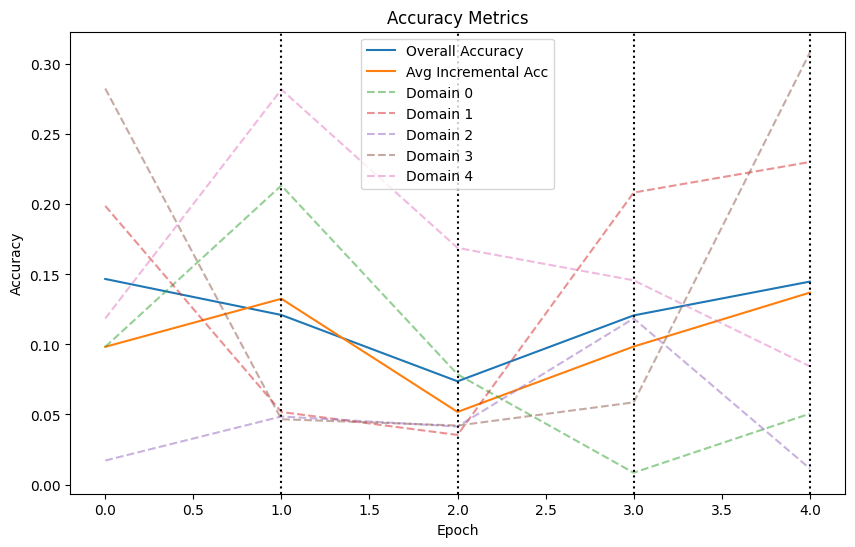

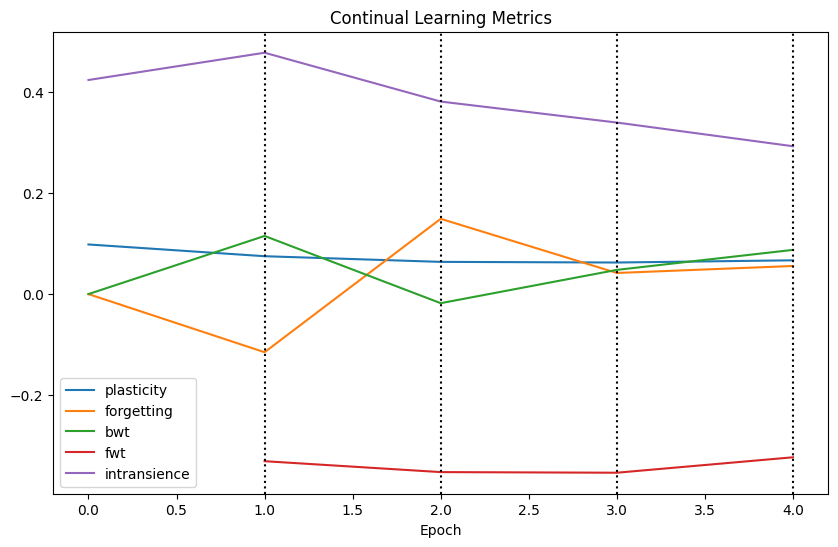

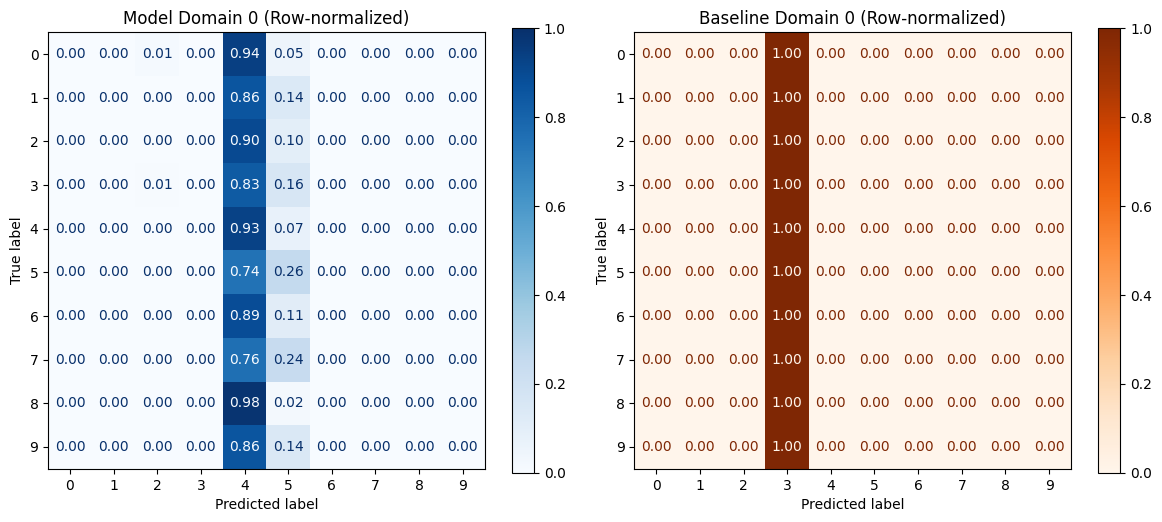

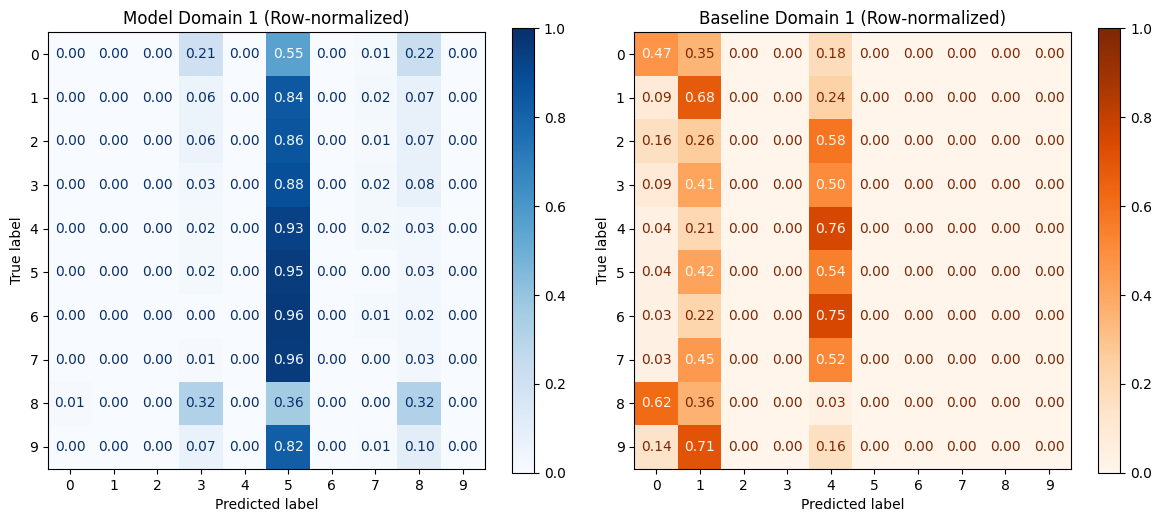

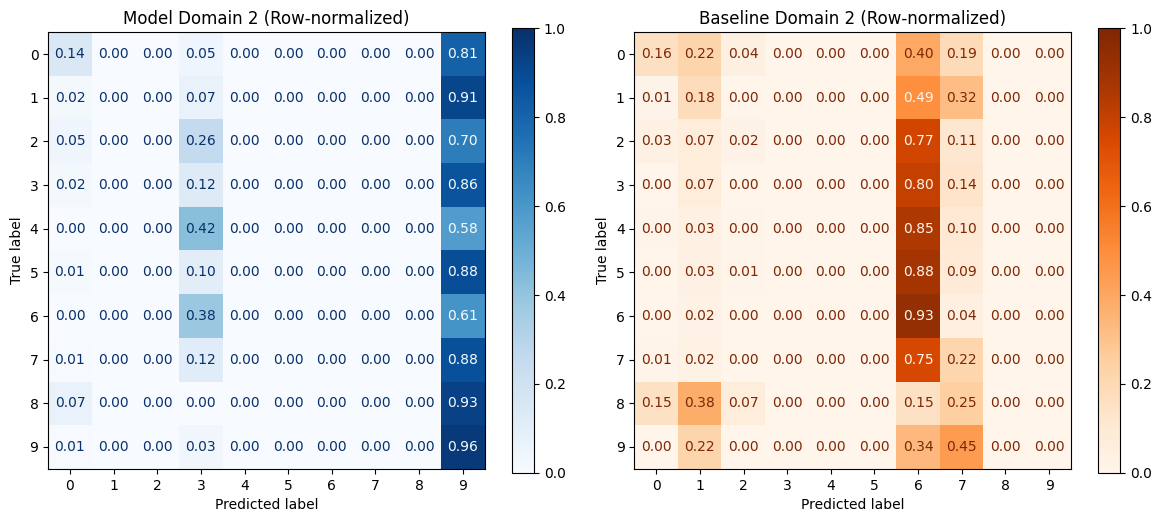

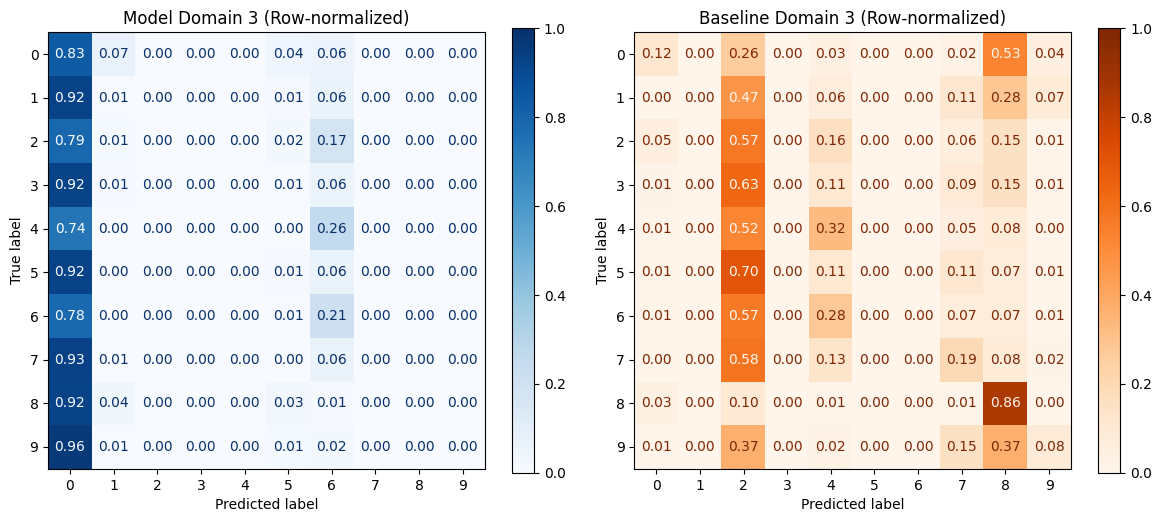

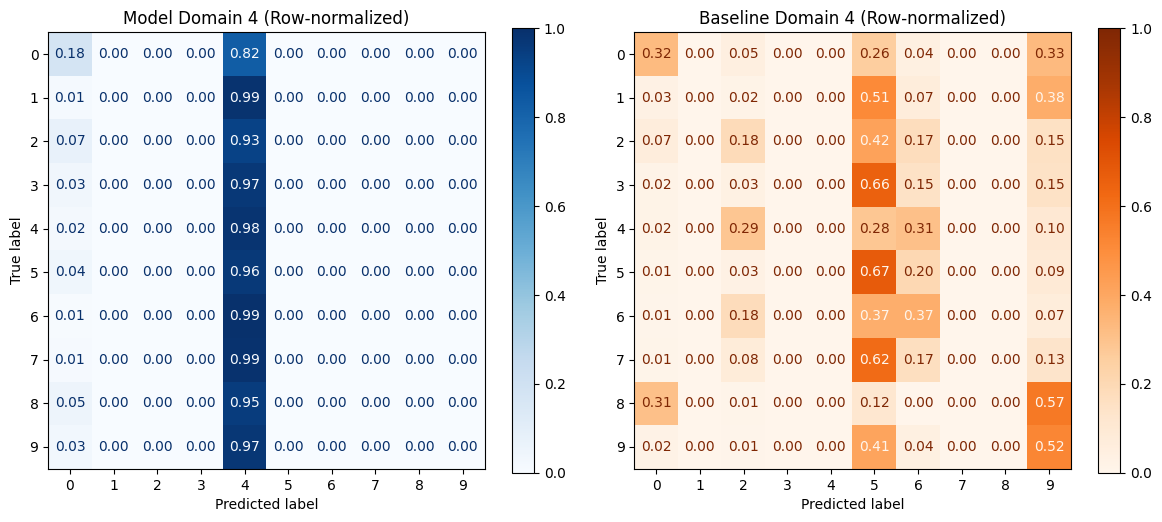

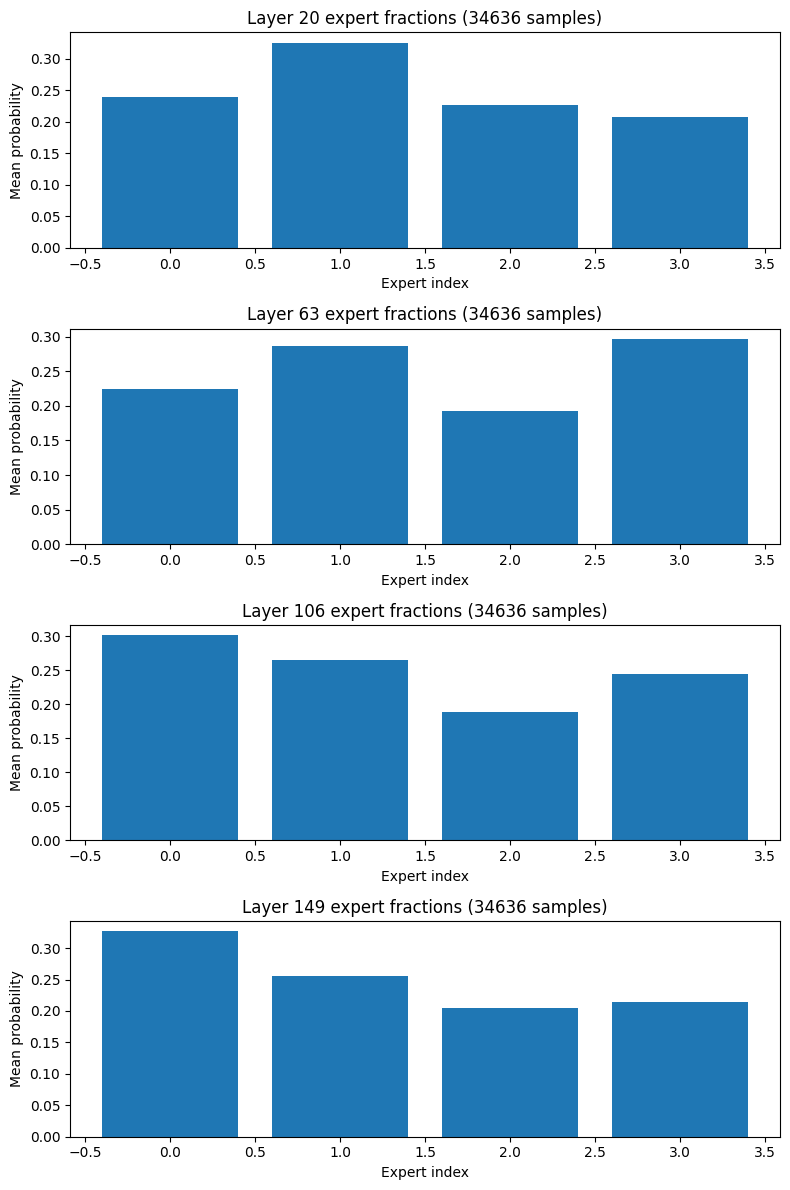

In [6]:
# ----------------------------------------
# Save and Plot
# ----------------------------------------
logger_save_path = logger.save()
plot_results(logger_save_path)

# expert load plot if MoE
plot_expert_loads(model)